In [1]:
import sys
import os
 
# Add project root to Python path
sys.path.append(os.path.abspath(".."))

In [2]:
from src.bayesian_network.label_data import label_dataset

raw_path = "../data/raw/bank_transactions_data_2.csv"
anomaly_path = "../results/dbscan/dbscan_anomaly_table.csv"
output_path = "../data/processed/bank_transactions_labeled.csv"

df_labeled = label_dataset(raw_path, anomaly_path, output_path)

In [3]:
import pandas as pd

df = pd.read_csv("../data/raw/bank_transactions_data_2.csv")
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


In [8]:
from src.bayesian_network.preprocess_bn import discretize_dataset

df_disc = discretize_dataset(df)
df_disc = df_disc.drop(columns=["time_since_prev"])
df_disc["time_of_day"] = df_disc["time_of_day"].astype("category").cat.codes
df_disc.head()


c:\Users\tewod\fraud-detection-unsupervised-learning\venv\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\tewod\fraud-detection-unsupervised-learning\venv\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\tewod\fraud-detection-unsupervised-learning\venv\lib\site-packages\sklearn\preprocessing\_discr

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,txn_dayofweek,time_of_day
0,0,1,36,0,3,0,1,0,2,1,2
1,2,1,15,0,3,0,2,0,3,1,2
2,1,1,23,2,0,3,0,0,0,0,3
3,1,1,33,2,0,3,0,0,3,4,2
4,0,0,1,2,0,3,3,0,2,0,2


In [ ]:
from src.bayesian_network.structure_learning import learn_structure
from src.bayesian_network.cpd_learning import learn_cpds

structure_model = learn_structure(df_disc)
print(structure_model.edges())
bn_model = learn_cpds(df_disc, structure_model)

  0%|          | 3/1000000 [00:00<29:11:55,  9.51it/s]


[('TransactionType', 'Channel'), ('CustomerAge', 'CustomerOccupation'), ('CustomerOccupation', 'AccountBalance')]


In [13]:
for cpd in bn_model.get_cpds():
    print(cpd)

+--------------------+----------+
| TransactionType(0) | 0.226659 |
+--------------------+----------+
| TransactionType(1) | 0.773341 |
+--------------------+----------+
+-----------------+---------------------+---------------------+
| TransactionType | TransactionType(0)  | TransactionType(1)  |
+-----------------+---------------------+---------------------+
| Channel(0)      | 0.1294186386210926  | 0.3908725062077233  |
+-----------------+---------------------+---------------------+
| Channel(1)      | 0.4414256500146071  | 0.31740731226988617 |
+-----------------+---------------------+---------------------+
| Channel(2)      | 0.42915571136430036 | 0.29172018152239065 |
+-----------------+---------------------+---------------------+
+----------------+----------+
| CustomerAge(0) | 0.223381 |
+----------------+----------+
| CustomerAge(1) | 0.269468 |
+----------------+----------+
| CustomerAge(2) | 0.24563  |
+----------------+----------+
| CustomerAge(3) | 0.261522 |
+-------------

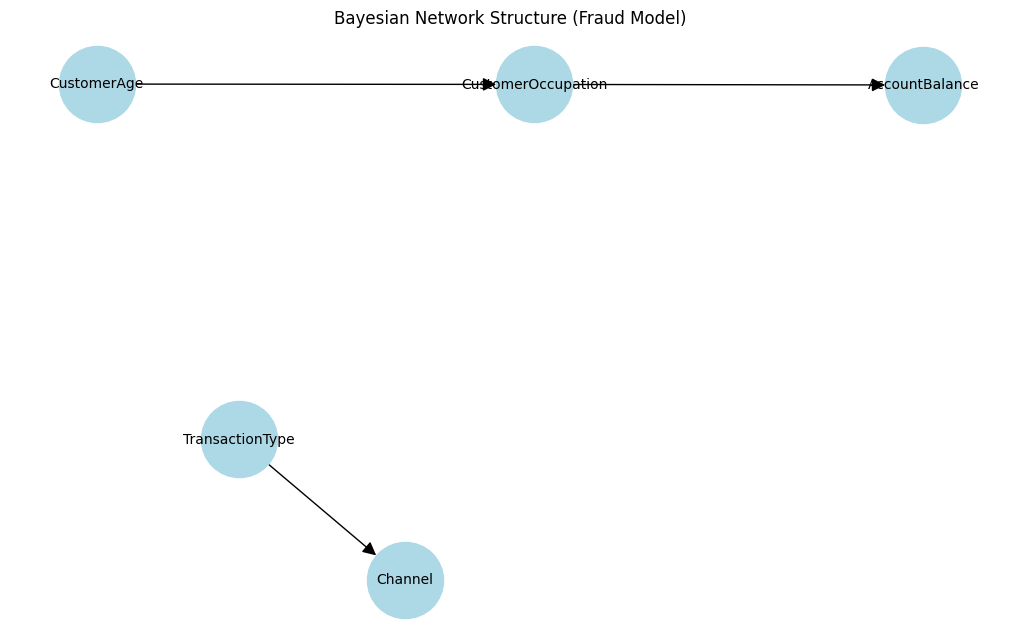

In [ ]:
from src.bayesian_network.network_visualization import visualize_bn

visualize_bn(bn_model) 

---

# 📊 Bayesian Network Analysis (Structure + CPDs)

## **1. Learned Structure**

```python
print(structure_model.edges())
```

**Result:**

```
[
 ('TransactionType', 'Channel'),
 ('CustomerAge', 'CustomerOccupation'),
 ('CustomerOccupation', 'AccountBalance')
]
```

---

## 🧠 Interpretation of Structure

The learned Bayesian Network reveals **two independent probabilistic subsystems**:

---

### 🔹 **(A) Transaction Behavior Subsystem**

```
TransactionType → Channel
```

**Meaning:**

- The type of transaction strongly influences the channel used.
- Example:  
  Certain transaction types are more likely to occur via ATM vs online.

---

### 🔹 **(B) Customer Profile Subsystem**

```
CustomerAge → CustomerOccupation → AccountBalance
```

**Meaning:**

- Age influences occupation category.  
- Occupation influences account balance distribution.  
- This forms a demographic → financial dependency chain.

---

### ⚠️ Key Observation

The network is **not fully connected**, meaning:

- Transaction behavior and customer financial behavior are **not strongly linked**.
- This suggests:
  - Weak statistical dependency after discretization, or  
  - Conservative structure learning due to BIC penalization.

---

## **2. Conditional Probability Distributions (CPDs)**

### 🔹 **P(TransactionType)**

```
TransactionType(0) = 0.226659
TransactionType(1) = 0.773341
```

**Interpretation:**  
The dataset is dominated by `TransactionType = 1`.

---

### 🔹 **P(Channel | TransactionType)**

| TransactionType | Channel 0 | Channel 1 | Channel 2 |
|-----------------|-----------|-----------|-----------|
| 0               | 0.1294    | 0.4414    | 0.4291    |
| 1               | 0.3908    | 0.3174    | 0.2917    |

**Interpretation:**

- Channel usage is strongly conditioned on transaction type.
- Type 0 prefers Channel 1 & 2.
- Type 1 shifts probability toward Channel 0.

---

### 🔹 **P(CustomerAge)**

Age groups are relatively balanced (~22%–26%).

**Interpretation:**  
Age alone is not highly informative.

---

### 🔹 **P(CustomerOccupation | CustomerAge)**

**Key insight:**

- One occupation class dominates (~65%).
- Age moderately influences occupation.

---

### 🔹 **P(AccountBalance | CustomerOccupation)**

| Occupation | Dominant Balance State |
|------------|-------------------------|
| 0          | 0.69                    |
| 1          | 0.23                    |
| 2          | 0.04                    |
| 3          | 0.03                    |

**Interpretation:**  
Occupation strongly influences account balance.  
Most users fall into a low‑balance dominant state.

---

## 🚨 **3. Overall Model Insight**

### ✔ Strengths

- Captures demographic → financial relationships  
- Captures transaction → channel dependency  
- Produces interpretable probabilistic reasoning  

### ⚠️ Limitations

- Graph is partially disconnected  
- Transaction behavior and financial behavior are weakly linked  
- Model may under‑represent cross‑domain fraud patterns  

---
